#### 데이터 불러오기 및 확인하기 (Load and examine the data)

이번에는 보험 요금(insurance charges) 데이터셋을 사용합니다.

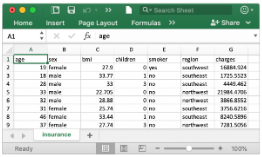

목표는:
왜 어떤 고객들은 보험료를 더 많이 내는지 분석하는 것
입니다.

#### 데이터 불러오기

```python
# Path of the file to read
insurance_filepath = "../input/insurance.csv"

# Read the file into a variable insurance_data
insurance_data = pd.read_csv(insurance_filepath)
```

#### 설명

* pd.read_csv()
CSV 파일 읽기

* 저장 변수
insurance_data
에 데이터 저장

* 데이터 확인하기
insurance_data.head()

* 출력 예시

| age | sex    | bmi  | children | smoker | region    | charges |
| --- | ------ | ---- | -------- | ------ | --------- | ------- |
| 19  | female | 27.9 | 0        | yes    | southwest | 16884   |

* 컬럼 의미
| 컬럼       | 의미         |
| -------- | ---------- |
| age      | 나이         |
| sex      | 성별         |
| bmi      | 체질량지수(BMI) |
| children | 자녀 수       |
| smoker   | 흡연 여부      |
| region   | 지역         |
| charges  | 보험료        |


#### Scatter Plot (산점도)

산점도는:
두 변수의 관계를 점으로 표현하는 그래프
입니다.

#### 기본 산점도 만들기

```python
sns.scatterplot(
    x=insurance_data['bmi'],
    y=insurance_data['charges']
)
```

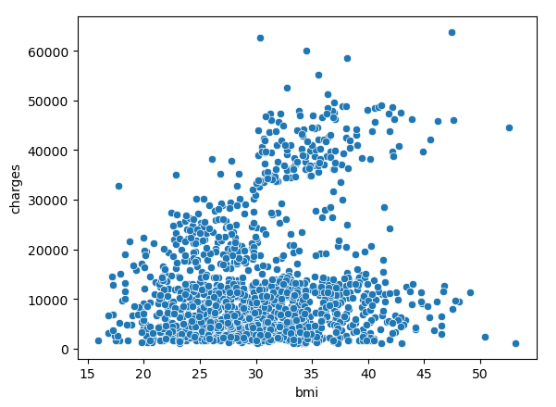

#### 설명
#### x축

```python
x=insurance_data['bmi']
```
BMI 값

#### y축

```python
y=insurance_data['charges']
```
보험료(charges)

#### 그래프 해석

그래프를 보면:
BMI가 높을수록 보험료도 증가하는 경향
이 보입니다.

즉:
* 양의 상관관계(positive correlation)
가 존재합니다.

#### 왜 이런 현상이 생길까?

BMI가 높으면:
* 만성 질환 위험 증가
* 건강 리스크 증가
→ 보험료 증가 가능성

#### Regression Plot (회귀선 추가)

관계의 강도를 더 명확하게 보기 위해:
데이터에 가장 잘 맞는 직선(regression line)
을 추가할 수 있습니다.

#### 코드

```python
sns.regplot(
    x=insurance_data['bmi'],
    y=insurance_data['charges']
)
```

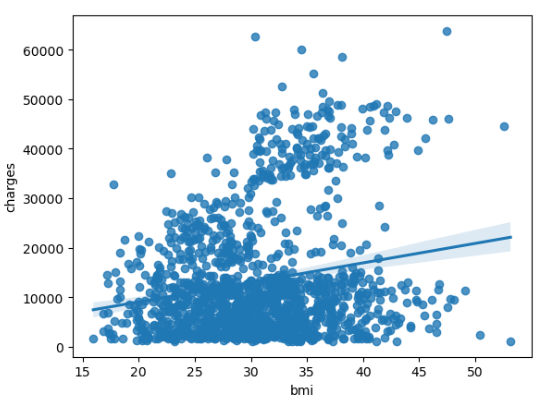

* sns.regplot()
scatter plot + regression line
을 함께 그립니다.

#### 그래프 해석

직선 기울기가 양수이므로:
BMI 증가 → 보험료 증가
경향이 더욱 명확하게 보입니다.

#### 색깔로 구분된 산점도 (Color-coded scatter plots)

이제:
2개가 아니라 3개의 변수 관계
를 시각화해봅니다.

#### 목표

흡연 여부(smoker)가:
* BMI
* 보험료 관계
에 어떤 영향을 미치는지 분석

#### 코드

```python
sns.scatterplot(
    x=insurance_data['bmi'],
    y=insurance_data['charges'],
    hue=insurance_data['smoker']
)
```

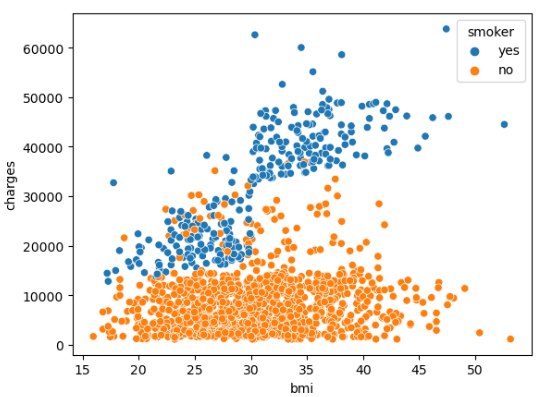

#### 핵심 옵션: hue

```python
hue=insurance_data['smoker']
```
색상으로 smoker 여부 구분

예:
* yes → 한 색
* no → 다른 색

#### 그래프 해석

그래프를 보면:
* 비흡연자(non-smoker)
→ BMI 증가 시 보험료 약간 증가
* 흡연자(smoker)
→ 보험료가 훨씬 크게 증가

즉:
흡연이 보험료에 매우 큰 영향
을 미칩니다.

#### 두 개의 회귀선 추가하기

이 차이를 더 강조하기 위해:
* 흡연자용 회귀선
* 비흡연자용 회귀선
을 각각 그립니다.

#### 코드

```python
sns.lmplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=insurance_data
)
```

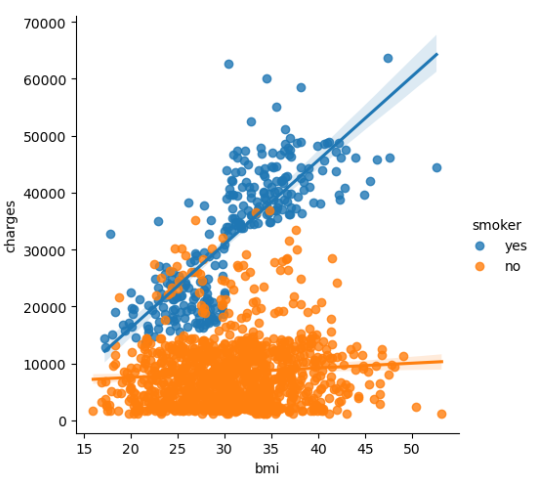

####  sns.lmplot() 특징
기존 함수와 사용법이 약간 다릅니다.

#### 차이점 1: 컬럼 이름만 문자열로 사용

기존:
```python
x=insurance_data['bmi']
```

lmplot:
```python
x="bmi"
```

즉:
* 컬럼 자체가 아니라
* 컬럼 이름 문자열 사용

#### 차이점 2: 데이터셋 따로 지정

```python
data=insurance_data
```
를 추가해야 함

#### 그래프 해석

흡연자 회귀선의 기울기가 훨씬 가파름

즉:
흡연자는 BMI 증가에 따라 보험료가 급격히 증가
함을 의미

#### Categorical Scatter Plot (범주형 산점도)

보통 산점도는:
* 연속형 변수 vs 연속형 변수
를 비교합니다.

예:
* bmi
* charges

하지만 이번에는:
범주형 변수(smoker)
를 x축에 배치해봅니다.

#### 코드

```python
sns.swarmplot(
    x=insurance_data['smoker'],
    y=insurance_data['charges']
)
```

* sns.swarmplot()
점들이 겹치지 않도록 자동 배치하는 categorical scatter plot

#### 경고 메시지 해석

```python
UserWarning: points cannot be placed
```

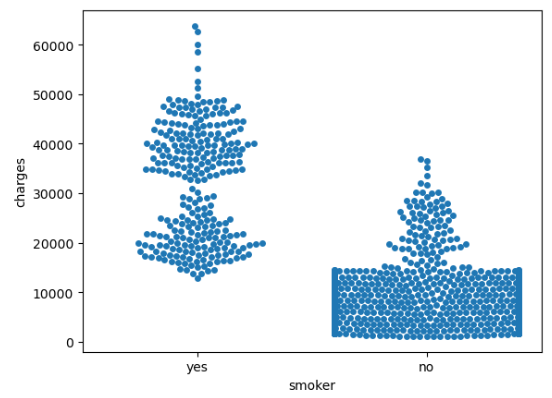

의미:
* 데이터가 너무 많아 점들이 겹침
하지만 큰 문제는 아닙니다.

#### 그래프 해석

이 그래프는 다음 사실을 보여줍니다.

* 1. 비흡연자가 평균적으로 보험료가 낮음
    non-smoker 그룹이 아래쪽에 몰려 있음
* 2. 가장 비싼 보험료 고객은 흡연자
    높은 charges 값 대부분이 smoker
* 3. 가장 저렴한 고객은 비흡연자
    낮은 charges 값 대부분이 non-smoker